In [1]:
import pandas as pd
df = pd.read_csv("G9hPjUGJv0UYj9I3rIDu90w9ycVmX3s4.csv")
df.head()

,Response_ID,Respondent_Age,Respondent_Gender,Satisfaction_Score,Recommend,Comments,Extra_1,Extra_2
0,S551093,80.0,Male,5.0,Maybe,Evidence point soon police bad he current rela...,property,support
1,S433109,52.0,Male,NaN,Yes,Somebody require allow performance head board ...,above,PM
2,S474506,NaN,Female,4.0,Yes,Act foreign they evening conference first loss.,ok,safe
3,S993895,53.0,Male,5.0,No,Glass her yourself far campaign local responsi...,town,its
4,S389466,70.0,Other,4.0,Yes,Blue from Mrs hotel sit turn sense data growth...,each,traditional


In [36]:
# نظره علي وصف البيانات لمعرفه أسماء الاعمده و نوع كل عمود و عدد الصفوف
df.info
df.head()

,Response_ID,Respondent_Age,Respondent_Gender,Satisfaction_Score,Recommend,Comments,Extra_1,Extra_2
0,S551093,80.000000,Male,5.000000,Maybe,Evidence point soon police bad he current rela...,property,support
1,S433109,52.000000,Male,2.954338,Yes,Somebody require allow performance head board ...,above,PM
2,S474506,49.252809,Female,4.000000,Yes,Act foreign they evening conference first loss.,ok,safe
3,S993895,53.000000,Male,5.000000,No,Glass her yourself far campaign local responsi...,town,its
4,S389466,70.000000,Other,4.000000,Yes,Blue from Mrs hotel sit turn sense data growth...,each,traditional


In [35]:
# نعرف علي جوده البيانات و معرفه القيم المفقوده
df.isnull().mean()*100

,0
Response_ID,0.0
Respondent_Age,0.0
Respondent_Gender,0.0
Satisfaction_Score,0.0
Recommend,0.0
Comments,0.0
Extra_1,0.0
Extra_2,0.0


In [34]:
# التكرارات
df.duplicated().sum()

np.int64(0)

(Data cleaning) تنظيف البيانات

In [2]:
# حذف القيم المتكرره
df = df.drop_duplicates()

In [4]:
#التعامل مع القيم المفقوده
df.isnull().sum()

,0
Response_ID,0
Respondent_Age,188
Respondent_Gender,0
Satisfaction_Score,531
Recommend,0
Comments,0
Extra_1,0
Extra_2,0


In [7]:
# القيم المفقوده عندنا 155 صف ناقص بالعمر و 531 صف ناقص بالتقييم
# هيتم التعامل مع هذه القيم المفقوده بالمتوسط

# تعويض العمر بالمتوسط
df["Respondent_Age"].fillna(df["Respondent_Age"].mean(), inplace=True)

/tmp/ipykernel_486/89555578.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Respondent_Age"].fillna(df["Respondent_Age"].mean(), inplace=True)


In [8]:
# تعويض التقييم بالمتوسط
df["Satisfaction_Score"].fillna(df["Satisfaction_Score"]. mean(), inplace=True)

/tmp/ipykernel_486/3668077108.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Satisfaction_Score"].fillna(df["Satisfaction_Score"]. mean(), inplace=True)


In [9]:
# تأكد من ان مفيش قيم مفقوده تاني
df.isnull().sum()

,0
Response_ID,0
Respondent_Age,0
Respondent_Gender,0
Satisfaction_Score,0
Recommend,0
Comments,0
Extra_1,0
Extra_2,0


ملحوظه علي الخطوه السابقه
تم تعويض القيم المفقوده في الاعمده الرقميه باستخدام المتوسط للحفاظ علي حجم البيانات و تجنب فقدان معلومات مهمه

In [10]:
# توزيع العملاء
df["Respondent_Gender"].value_counts()

,count
Respondent_Gender,
Female,859
Male,857
Other,786


In [12]:
df["Satisfaction_Score"]= pd.to_numeric(df["Satisfaction_Score"], errors="coerce")

In [13]:
df["Satisfaction_Score"].fillna(df["Satisfaction_Score"]. mean(), inplace=True)

/tmp/ipykernel_486/1615897589.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Satisfaction_Score"].fillna(df["Satisfaction_Score"]. mean(), inplace=True)


In [52]:
# حساب متوسط اعمار العملاء
df["Respondent_Age"].mean()

np.float64(49.252808988764045)

In [16]:
# بعض القيم في عمود التقييم كانت مخزنه كقوائم[list]
# لذالك استخدمنا explode لتحويل كل عنصر داخل القائمه الي صف منفصل
# مما يجعل البيانات في شكل مناسب للتحليل الاحصائي

df = df.explode("Satisfaction_Score")

In [18]:
# عرض اول 5 قيم من عمود التقييم لفهم شكل البيانات و التأكد من محتواها
df["Satisfaction_Score"].head()

,Satisfaction_Score
0,5.000000
1,2.954338
2,4.000000
3,5.000000
4,4.000000


In [22]:
# تحسين شكل الأرقام في العرض
df.groupby("Respondent_Gender")["Satisfaction_Score"].mean().round(2)

,Satisfaction_Score
Respondent_Gender,
Female,2.98
Male,2.95
Other,2.93


In [23]:
# معرفه عدد التوصيات
df["Recommend"].value_counts()

,count
Recommend,
Maybe,889
No,823
Yes,790


In [26]:
# توضيح نسبه كل فئه
df["Recommend"].value_counts(normalize=True)*100

,proportion
Recommend,
Maybe,35.531575
No,32.893685
Yes,31.574740


In [37]:
# علاقه التوصيات بالرضا
# Yes اعلي من المتوسط
# No  اقل من المتوسط
# Maybe المتوسط


df.groupby("Recommend")["Satisfaction_Score"].mean()

,Satisfaction_Score
Recommend,
Maybe,2.970353
No,2.971676
Yes,2.918253


<Axes: ylabel='count'>

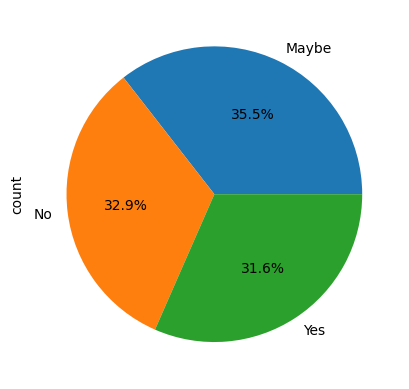

In [39]:
# Pie chart رسم بياني
df["Recommend"].value_counts().plot(kind='pie', autopct="%1.1f%%")

<Axes: xlabel='Recommend'>

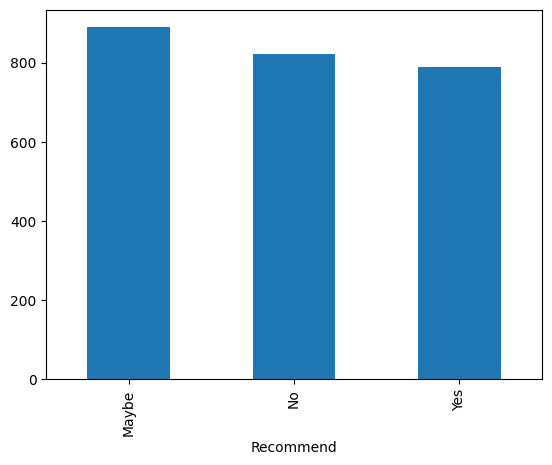

In [30]:
# Bar chart رسم بياني
df["Recommend"].value_counts().plot(kind="bar")

<Axes: >

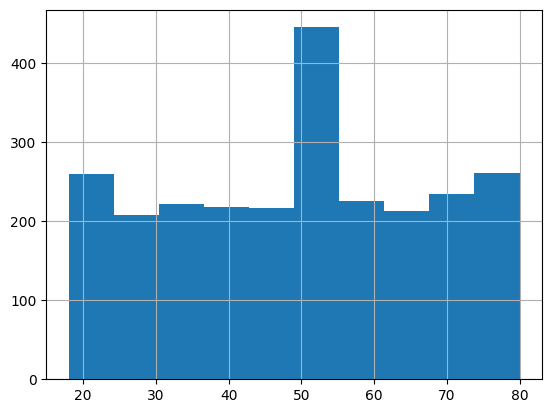

In [48]:
# رسم بياني يوضح توزيع الاعمار
df["Respondent_Age"].hist()

In [47]:
# رسم بياني يوضح مقارنه الجنس بالتوصيه
df.groupby(["Respondent_Gender", "Recommend"]).size()

Respondent_Gender  Recommend
Female             Maybe        285
                   No           287
                   Yes          287
Male               Maybe        292
                   No           293
                   Yes          272
Other              Maybe        312
                   No           243
                   Yes          231
dtype: int64

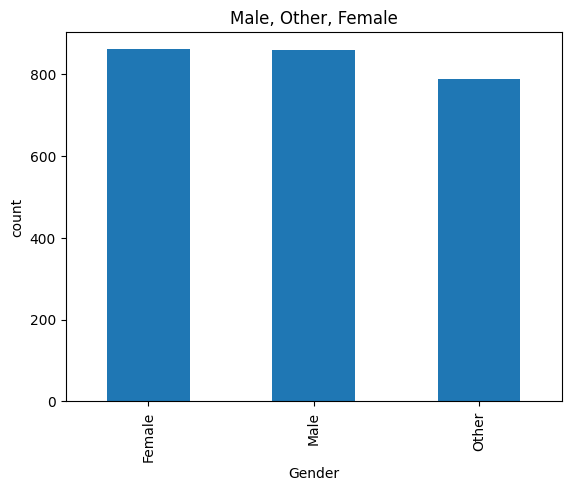

In [50]:
# Bar chart رسم بسيط
import matplotlib.pyplot as plt
df["Respondent_Gender"].value_counts().plot(kind="bar")
plt.title("Male, Other, Female")
plt.xlabel("Gender")
plt.ylabel("count")
plt.show()